In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import KFold

from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)
#from google.colab import drive
#drive.mount('/content/drive')

# Logistic classifier *with enforcement of biological constraints* as a post-processing layer


We can enforce biological rules in two ways on one-vs-rest logistic classifier

A. Enforce biological constraints as a post processing layer. Training remains invariate with respect to the base logistic classifier in notebook 3, but in the prediction stage scores are forced to 0 whenever the interaction is not biologically possible. 


B. Restrict the interactions that must be tested. E.g., if residue pair is (tryptofan, tryptofan), the SSBOND classifier doesnt even start. Each classifier will see just the examples where the label is biologically possible, and will learn to distinguish the cases where it is there and where it is not there.


Compare results with those of the base logistic classifier. In this notebook we do option A, which does not require training a new model.


List of biological impossibility rules:

HBOND | no hard residue-name rule; backbone can participate

VDW | no hard residue-name rule; any residues can make van der Waals contacts

IONIC | requires one acidic and one basic residue

PIPISTACK | requires both residues to be aromatic

PICATION | requires one aromatic and one positively charged residue

SSBOND | requires both residues to be cysteine

PIHBOND | requires at least one aromatic residue



The most likely rules to be safe are SSBOND, PIPISTACK, and PICATION. The IONIC and PIHBOND rules are still biologically reasonable, but you should validate them against your labels because the annotation tool may include borderline cases, protonation-state assumptions, or backbone-mediated interactions.

---
#### Import data and pretrained model

In [2]:
train_df = pd.read_parquet("classification_ring/data/processed/train.parquet")
val_df = pd.read_parquet("classification_ring/data/processed/val.parquet") # dont load the test set yet, we will use it only at the very end to evaluate the final classifier
train_df.head()

,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_a5,t_3di_state,t_3di_letter,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
0,2i49,A,444,,L,H,0.073,-0.990,-0.759,-1.019,...,1.648,5.0,F,0,0,0,0,0,0,1
1,2i49,A,157,,A,-,0.000,-1.132,2.664,-0.591,...,-0.078,1.0,B,1,0,0,0,0,0,1
2,2i49,A,81,,G,T,0.357,1.342,0.258,-0.384,...,1.648,17.0,R,1,0,0,0,0,0,0
3,2i49,A,172,,A,G,0.009,-1.754,0.040,-0.591,...,0.816,13.0,N,1,0,0,0,0,0,0
4,2i49,A,316,,G,S,0.310,-0.955,2.750,-0.384,...,0.933,17.0,R,1,0,0,0,0,0,1


In [3]:
# Import the pretrained logistic classifier

load_model_bool = True

if load_model_bool:
    import pickle
    model_path = "classification_ring/models/logistic_classifier/logistic_model.pkl"
    with open(model_path, "rb") as f:
        pipeline = pickle.load(f)
    print(f"Model loaded from {model_path}")

# Import the results of the basline logistic classifier (without biological constraints) to compare with the results of the constrained classifier

load_baseline_metrics_bool = True
if load_baseline_metrics_bool:
    baseline_threshold_results_df = pd.read_parquet("classification_ring/models/logistic_classifier/threshold_results.parquet")
    baseline_curve_results_df = pd.read_parquet("classification_ring/models/logistic_classifier/curve_results.parquet")
    print("Baseline metrics loaded.")

Model loaded from classification_ring/models/logistic_classifier/logistic_model.pkl
Baseline metrics loaded.


Preparation of X and Y

In [13]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']
target_names = label_cols # alias used in the plotting functions

#Numerical features
num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    's_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    't_3di_state'
]

#Categorical features
cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]



feature_cols = num_features + cat_features


X_train = train_df[feature_cols]
Y_train = train_df[label_cols]
X_train_names = train_df[["s_resn", "t_resn"]]


X_val = val_df[feature_cols]
Y_val = val_df[label_cols]
X_val_names = val_df[["s_resn", "t_resn"]]

print("X_val shape:", X_val.shape)
print("X_val_names shape:", X_val_names.shape)
print("Y_val shape:", Y_val.shape)

X_val shape: (238810, 22)
X_val_names shape: (238810, 2)
Y_val shape: (238810, 7)


Check if enforced rules are safe

In [5]:
def check_constraint_violations(Y, X_names):

    s_resn = X_names["s_resn"].str.upper()
    t_resn = X_names["t_resn"].str.upper()

    acidic = {"D", "E"}
    basic = {"K", "R", "H"}
    aromatic = {"F", "Y", "W", "H"}
    cysteine = {"C"}

    masks = {
        "IONIC": (
            (s_resn.isin(acidic) & t_resn.isin(basic)) |
            (t_resn.isin(acidic) & s_resn.isin(basic))
        ),

        "PIPISTACK": (
            s_resn.isin(aromatic) &
            t_resn.isin(aromatic)
        ),

        "PICATION": (
            (s_resn.isin(aromatic) & t_resn.isin(basic)) |
            (t_resn.isin(aromatic) & s_resn.isin(basic))
        ),

        "SSBOND": (
            s_resn.isin(cysteine) &
            t_resn.isin(cysteine)
        ),

        "PIHBOND": (
            s_resn.isin(aromatic) |
            t_resn.isin(aromatic)
        )
    }

    results = []

    for label, mask in masks.items():

        n_true = Y[label].sum()

        n_violations = (
            (Y[label] == 1) &
            (~mask)
        ).sum()

        results.append({
            "label": label,
            "n_true_positives": n_true,
            "n_true_positives_violating_rule": n_violations,
            "fraction_violating_rule": n_violations / n_true if n_true > 0 else np.nan
        })

    return pd.DataFrame(results)

In [6]:
constraint_check_df = check_constraint_violations(
    Y=Y_train,
    X_names=X_train_names
)

constraint_check_df

,label,n_true_positives,n_true_positives_violating_rule,fraction_violating_rule
0,IONIC,24650,4,0.000162
1,PIPISTACK,26619,8,0.000301
2,PICATION,6085,3,0.000493
3,SSBOND,1345,0,0.000000
4,PIHBOND,1322,0,0.000000


Mostly.

---
#### Predict with constraints on the validation set

In [7]:
def predict_with_constraints(pipeline, X, X_names, threshold=0.5):

    label_cols = [
        'HBOND', 'VDW', 'IONIC', 'PIPISTACK',
        'PICATION', 'SSBOND', 'PIHBOND'
    ]

    # ------------------------------------------------------------
    # 1. Get predicted probabilities
    # ------------------------------------------------------------

    y_proba = pipeline.predict_proba(X)

    proba_df = pd.DataFrame(
        np.column_stack([
            y_proba[i][:, 1] for i in range(len(label_cols))
        ]),
        columns=label_cols,
        index=X.index
    )

    # ------------------------------------------------------------
    # 2. Get residue names, assuming one-letter amino acid codes
    # ------------------------------------------------------------

    s_resn = X_names["s_resn"].str.upper()
    t_resn = X_names["t_resn"].str.upper()

    # ------------------------------------------------------------
    # 3. Define residue groups using one-letter codes
    # ------------------------------------------------------------

    acidic = {"D", "E"}        # Aspartate, Glutamate
    basic = {"K", "R", "H"}   # Lysine, Arginine, Histidine
    aromatic = {"F", "Y", "W", "H"}  # Phenylalanine, Tyrosine, Tryptophan, Histidine
    cysteine = {"C"}          # Cysteine

    # ------------------------------------------------------------
    # 4. Define biological feasibility masks
    # ------------------------------------------------------------

    ionic_possible = (
        (s_resn.isin(acidic) & t_resn.isin(basic)) |
        (t_resn.isin(acidic) & s_resn.isin(basic))
    )

    pipistack_possible = (
        s_resn.isin(aromatic) &
        t_resn.isin(aromatic)
    )

    pication_possible = (
        (s_resn.isin(aromatic) & t_resn.isin(basic)) |
        (t_resn.isin(aromatic) & s_resn.isin(basic))
    )

    ssbond_possible = (
        s_resn.isin(cysteine) &
        t_resn.isin(cysteine)
    )

    pihbond_possible = (
        s_resn.isin(aromatic) |
        t_resn.isin(aromatic)
    )

    # ------------------------------------------------------------
    # 5. Apply constraints
    # ------------------------------------------------------------

    proba_constrained_df = proba_df.copy()

    proba_constrained_df.loc[~ionic_possible, "IONIC"] = 0.0
    proba_constrained_df.loc[~pipistack_possible, "PIPISTACK"] = 0.0
    proba_constrained_df.loc[~pication_possible, "PICATION"] = 0.0
    proba_constrained_df.loc[~ssbond_possible, "SSBOND"] = 0.0
    proba_constrained_df.loc[~pihbond_possible, "PIHBOND"] = 0.0

    # ------------------------------------------------------------
    # 6. Threshold constrained probabilities
    # ------------------------------------------------------------

    y_pred = (
        proba_constrained_df > threshold
    ).astype(int)

    return y_pred, proba_constrained_df

#### Compute (or reload) metrics for the constrained prediction

In [8]:
compute_metrics_bool = False

if compute_metrics_bool:

    # Compute all metrics and stores in dataframes

    target_names = label_cols

    # ------------------------------------------------------------
    # 1. Get predicted probabilities
    # ------------------------------------------------------------

    y_pred, proba_constrained_df = predict_with_constraints(pipeline, X_val, X_val_names, threshold=0.5)
    y_scores = proba_constrained_df.values

    thresholds = np.arange(0.00, 1.01, 0.01)

    threshold_results = []
    curve_results = []

    # ------------------------------------------------------------
    # 2. Compute metrics class by class
    # ------------------------------------------------------------

    for class_idx, class_name in enumerate(target_names):

        y_true = Y_val.iloc[:, class_idx].values
        y_score = y_scores[:, class_idx]

        # --------------------------------------------------------
        # Threshold-dependent metrics
        # --------------------------------------------------------

        for threshold in thresholds:

            y_pred = (y_score > threshold).astype(int)

            threshold_results.append({
                "class": class_name,
                "threshold": threshold,
                "MCC": matthews_corrcoef(y_true, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
            })

        # --------------------------------------------------------
        # Threshold-independent curve data
        # --------------------------------------------------------

        precision, recall, pr_thresholds = precision_recall_curve(
            y_true,
            y_score
        )

        fpr, tpr, roc_thresholds = roc_curve(
            y_true,
            y_score
        )

        ap = average_precision_score(
            y_true,
            y_score
        )

        auc = roc_auc_score(
            y_true,
            y_score
        )

        curve_results.append({
            "class": class_name,
            "precision": precision,
            "recall": recall,
            "pr_thresholds": pr_thresholds,
            "fpr": fpr,
            "tpr": tpr,
            "roc_thresholds": roc_thresholds,
            "average_precision": ap,
            "ROC_AUC": auc
        })

    # ------------------------------------------------------------
    # 3. Convert to DataFrames
    # ------------------------------------------------------------

    postprocessed_threshold_results_df = pd.DataFrame(threshold_results)
    postprocessed_curve_results_df = pd.DataFrame(curve_results)

    # ------------------------------------------------------------
    # 4. Save to files
    # ------------------------------------------------------------

    postprocessed_threshold_results_df.to_parquet("classification_ring/models/logistic_classifier/postprocessed_threshold_results.parquet", index=False)
    postprocessed_curve_results_df.to_parquet("classification_ring/models/logistic_classifier/postprocessed_curve_results.parquet", index=False)

In [9]:
load_metrics_bool = True

if load_metrics_bool:
    postprocessed_threshold_results_df = pd.read_parquet("classification_ring/models/logistic_classifier/postprocessed_threshold_results.parquet")
    postprocessed_curve_results_df = pd.read_parquet("classification_ring/models/logistic_classifier/postprocessed_curve_results.parquet")
    print("Post-processed metrics loaded.")

Post-processed metrics loaded.


In [26]:
postprocessed_curve_results_df.head()

,class,precision,recall,pr_thresholds,fpr,tpr,roc_thresholds,average_precision,ROC_AUC
0,HBOND,"[0.7272936644194129, 0.7272967099229929, 0.727...","[1.0, 1.0, 0.9999942424504131, 0.9999884849008...","[0.06727575013059651, 0.06902378001147602, 0.0...","[0.0, 0.0, 0.0, 4.6065259117082534e-05, 4.6065...","[0.0, 5.757549586895817e-06, 0.000132423640498...","[inf, 0.8908929001081001, 0.8744942245825986, ...",0.827902,0.668367
1,VDW,"[0.5065658892006197, 0.5065680104183679, 0.506...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999917336926...","[0.12674744665929102, 0.13461906691359163, 0.1...","[0.0, 8.48629887047362e-06, 8.48629887047362e-...","[0.0, 0.0, 1.653261471568036e-05, 1.6532614715...","[inf, 0.8133253160343671, 0.8012555307781084, ...",0.586199,0.592395
2,IONIC,"[0.02295548762614631, 0.31383100526677354, 0.3...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.06619152238156101, 0.09259003234948511...","[0.0, 0.0, 0.0, 4.285812247137078e-06, 4.28581...","[0.0, 0.00018241517694272163, 0.00145932141554...","[inf, 0.996151297911092, 0.995804480398816, 0....",0.499545,0.983881
3,PIPISTACK,"[0.024529961056907166, 0.7338093448578229, 0.7...","[1.0, 1.0, 1.0, 0.999829293274155, 0.999658586...","[0.0, 0.6396730732486031, 0.6651794512659384, ...","[0.0, 0.0, 0.0, 8.585459665510492e-06, 8.58545...","[0.0, 0.0001707067258449983, 0.001536360532604...","[inf, 0.9999991032714725, 0.9999990646450985, ...",0.776117,0.995894
4,PICATION,"[0.006276956576357774, 0.14831305036113585, 0....","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.05998973620209409, 0.06452910093565836...","[0.0, 0.0, 0.0, 1.6855518707518825e-05, 1.6855...","[0.0, 0.00066711140760507, 0.00266844563042028...","[inf, 0.9881326033757212, 0.9872369419114604, ...",0.285501,0.990314


---

# Compared Evaluation on the validation set

**Table 1/3** Comparison of global metrics

In [30]:
constrained_classes = [
    "IONIC",
    "PIPISTACK",
    "PICATION",
    "SSBOND",
    "PIHBOND"
]

postprocessed_curve_summary_df = postprocessed_curve_results_df[
    ["class", "average_precision", "ROC_AUC"]
].copy()

baseline_curve_summary_df = baseline_curve_results_df[
    ["class", "average_precision", "ROC_AUC"]
].copy()

curve_comparison_df = (
    baseline_curve_summary_df
    .merge(
        postprocessed_curve_summary_df,
        on="class",
        suffixes=("_baseline", "_postprocessed")
    )
)

curve_comparison_df["delta_ROC_AUC"] = (
    curve_comparison_df["ROC_AUC_postprocessed"]
    - curve_comparison_df["ROC_AUC_baseline"]
)

curve_comparison_df["delta_average_precision"] = (
    curve_comparison_df["average_precision_postprocessed"]
    - curve_comparison_df["average_precision_baseline"]
)

curve_comparison_df["constraint_applied"] = (
    curve_comparison_df["class"].isin(constrained_classes)
)

curve_comparison_df = curve_comparison_df[
    [
        "class",
        "constraint_applied",

        "ROC_AUC_baseline",
        "ROC_AUC_postprocessed",
        "delta_ROC_AUC",

        "average_precision_baseline",
        "average_precision_postprocessed",
        "delta_average_precision"
    ]
]

curve_comparison_df.round(3)

,class,constraint_applied,ROC_AUC_baseline,ROC_AUC_postprocessed,delta_ROC_AUC,average_precision_baseline,average_precision_postprocessed,delta_average_precision
0,HBOND,False,0.668,0.668,0.000,0.828,0.828,0.000
1,VDW,False,0.592,0.592,0.000,0.586,0.586,0.000
2,IONIC,True,0.966,0.984,0.018,0.316,0.500,0.184
3,PIPISTACK,True,0.981,0.996,0.014,0.459,0.776,0.317
4,PICATION,True,0.969,0.990,0.022,0.084,0.286,0.202
5,SSBOND,True,1.000,1.000,-0.000,0.887,0.887,0.000
6,PIHBOND,True,0.910,0.928,0.018,0.007,0.008,0.001


**Table 2/3:** Best-threshold metric comparison

In [33]:

def get_best_threshold_by_class(threshold_results_df, metric="MCC"):
    """
    For each class, select the threshold that maximizes the chosen metric.

    Expected columns:
    - class
    - threshold
    - MCC
    - balanced_accuracy
    """
    best_df = (
        threshold_results_df
        .sort_values(["class", metric], ascending=[True, False])
        .groupby("class", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    return best_df


# ------------------------------------------------------------
# 1. Select the MCC-optimal threshold for each class
# ------------------------------------------------------------

baseline_best_mcc_df = get_best_threshold_by_class(
    baseline_threshold_results_df,
    metric="MCC"
)

postprocessed_best_mcc_df = get_best_threshold_by_class(
    postprocessed_threshold_results_df,
    metric="MCC"
)


# ------------------------------------------------------------
# 2. Merge baseline and post-processed results
# ------------------------------------------------------------

best_threshold_comparison_df = (
    baseline_best_mcc_df
    .merge(
        postprocessed_best_mcc_df,
        on="class",
        suffixes=("_baseline", "_postprocessed")
    )
)


# ------------------------------------------------------------
# 3. Compute deltas
# ------------------------------------------------------------

best_threshold_comparison_df["delta_MCC"] = (
    best_threshold_comparison_df["MCC_postprocessed"]
    - best_threshold_comparison_df["MCC_baseline"]
)

best_threshold_comparison_df["delta_balanced_accuracy"] = (
    best_threshold_comparison_df["balanced_accuracy_postprocessed"]
    - best_threshold_comparison_df["balanced_accuracy_baseline"]
)


# ------------------------------------------------------------
# 4. Mark classes affected by biological constraints
# ------------------------------------------------------------

best_threshold_comparison_df["constraint_applied"] = (
    best_threshold_comparison_df["class"].isin(constrained_classes)
)


# ------------------------------------------------------------
# 5. Reorder columns for a clean report table
# ------------------------------------------------------------

best_threshold_comparison_df = best_threshold_comparison_df[
    [
        "class",
        "constraint_applied",

        "threshold_baseline",
        "threshold_postprocessed",

        "MCC_baseline",
        "MCC_postprocessed",
        "delta_MCC",

        "balanced_accuracy_baseline",
        "balanced_accuracy_postprocessed",
        "delta_balanced_accuracy"
    ]
]


# ------------------------------------------------------------
# 6. Display rounded table
# ------------------------------------------------------------

best_threshold_comparison_df.round(3)

,class,constraint_applied,threshold_baseline,threshold_postprocessed,MCC_baseline,MCC_postprocessed,delta_MCC,balanced_accuracy_baseline,balanced_accuracy_postprocessed,delta_balanced_accuracy
0,HBOND,False,0.43,0.43,0.228,0.228,0.000,0.613,0.613,0.000
1,IONIC,True,0.71,0.71,0.419,0.567,0.148,0.922,0.944,0.022
2,PICATION,True,0.74,0.74,0.312,0.444,0.133,0.948,0.962,0.014
3,PIHBOND,True,0.81,0.42,0.059,0.063,0.005,0.747,0.888,0.141
4,PIPISTACK,True,0.81,0.64,0.624,0.853,0.229,0.976,0.995,0.019
5,SSBOND,True,0.99,0.99,0.870,0.870,0.000,1.000,1.000,0.000
6,VDW,False,0.52,0.52,0.131,0.131,0.000,0.564,0.564,0.000


**Table 2/3:** Fixed-threshold metric comparison

In [34]:
fixed_threshold = 0.5

baseline_fixed_threshold_df = (
    baseline_threshold_results_df
    .loc[np.isclose(baseline_threshold_results_df["threshold"], fixed_threshold)]
    .copy()
)

postprocessed_fixed_threshold_df = (
    postprocessed_threshold_results_df
    .loc[np.isclose(postprocessed_threshold_results_df["threshold"], fixed_threshold)]
    .copy()
)

fixed_threshold_comparison_df = (
    baseline_fixed_threshold_df
    .merge(
        postprocessed_fixed_threshold_df,
        on="class",
        suffixes=("_baseline", "_postprocessed")
    )
)

fixed_threshold_comparison_df["delta_MCC"] = (
    fixed_threshold_comparison_df["MCC_postprocessed"]
    - fixed_threshold_comparison_df["MCC_baseline"]
)

fixed_threshold_comparison_df["delta_balanced_accuracy"] = (
    fixed_threshold_comparison_df["balanced_accuracy_postprocessed"]
    - fixed_threshold_comparison_df["balanced_accuracy_baseline"]
)

fixed_threshold_comparison_df["constraint_applied"] = (
    fixed_threshold_comparison_df["class"].isin(constrained_classes)
)

fixed_threshold_comparison_df = fixed_threshold_comparison_df[
    [
        "class",
        "constraint_applied",

        "threshold_baseline",
        "threshold_postprocessed",

        "MCC_baseline",
        "MCC_postprocessed",
        "delta_MCC",

        "balanced_accuracy_baseline",
        "balanced_accuracy_postprocessed",
        "delta_balanced_accuracy"
    ]
]

fixed_threshold_comparison_df.round(3)

,class,constraint_applied,threshold_baseline,threshold_postprocessed,MCC_baseline,MCC_postprocessed,delta_MCC,balanced_accuracy_baseline,balanced_accuracy_postprocessed,delta_balanced_accuracy
0,HBOND,False,0.5,0.5,0.219,0.219,0.000,0.621,0.621,0.000
1,VDW,False,0.5,0.5,0.130,0.130,0.000,0.565,0.565,0.000
2,IONIC,True,0.5,0.5,0.400,0.554,0.154,0.941,0.970,0.028
3,PIPISTACK,True,0.5,0.5,0.568,0.853,0.285,0.975,0.995,0.020
4,PICATION,True,0.5,0.5,0.271,0.408,0.138,0.963,0.984,0.022
5,SSBOND,True,0.5,0.5,0.863,0.867,0.004,1.000,1.000,0.000
6,PIHBOND,True,0.5,0.5,0.054,0.061,0.007,0.843,0.859,0.016


#### Inspection of the false positives 

In [19]:
# Baseline prevalence of each label in the validation set
label_prevalence = Y_val.mean().sort_values(ascending=False)

# First row of final dataframe
prevalence_rows = {
    "baseline": label_prevalence
}

false_positive_counts = {}

Y_pred = y_pred  # Use the predictions obtained from the constrained model

# Make sure Y_pred is a DataFrame with same columns/index as Y_val
Y_pred_df = pd.DataFrame(
    Y_pred,
    columns=Y_val.columns,
    index=Y_val.index
)

for class_idx, class_name in enumerate(target_names):

    # Samples predicted as class_name, but truly not class_name
    fp_mask = (Y_val.iloc[:, class_idx] == 0) & (Y_pred_df.iloc[:, class_idx] == 1)

    false_positives = Y_val.loc[fp_mask]

    n_fp = len(false_positives)
    false_positive_counts[class_name] = n_fp

    if n_fp == 0:
        print(f"\nNo false positives for {class_name}")
        continue

    # Drop the class itself, since it is necessarily 0 among its false positives
    false_positives_no_self = false_positives.drop(columns=[class_name])

    # Prevalence of true labels among false positives
    fp_label_prevalence = false_positives_no_self.mean()

    # Add as a row
    prevalence_rows[f"FP_{class_name}"] = fp_label_prevalence

# Final dataframe
fp_prevalence_df = pd.DataFrame(prevalence_rows).T

# Optional: inspect number of false positives per predicted class
false_positive_counts = pd.Series(false_positive_counts, name="n_false_positives")


display(fp_prevalence_df)
print(false_positive_counts)

,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
baseline,0.727294,0.022955,0.006277,0.000888,0.024530,0.001809,0.506566
FP_HBOND,NaN,0.012812,0.016896,0.001049,0.004271,0.000000,0.981531
FP_VDW,0.944421,0.024537,0.009297,0.001426,0.054153,0.003373,NaN
FP_IONIC,0.856733,NaN,0.000000,0.000000,0.000000,0.000000,0.488166
FP_PIPISTACK,0.616000,0.000000,0.000000,0.000000,NaN,0.000000,0.552941
FP_PICATION,0.619947,0.000000,NaN,0.002778,0.146270,0.000000,0.583137
FP_SSBOND,0.657343,0.000000,0.000000,0.000000,0.000000,NaN,0.538462
FP_PIHBOND,0.568387,0.005195,0.032096,NaN,0.169259,0.000000,0.574508


HBOND        26693
VDW          49803
IONIC        11154
PIPISTACK     2125
PICATION      7199
SSBOND         143
PIHBOND      33493
Name: n_false_positives, dtype: int64


In [20]:
enrichment_df = (fp_prevalence_df - fp_prevalence_df.loc["baseline"]) / fp_prevalence_df.loc["baseline"]
enrichment_df = enrichment_df.drop(index="baseline")  # Exclude the baseline row 
enrichment_df = enrichment_df[[class_name for class_name in target_names]]


display(enrichment_df)

,HBOND,VDW,IONIC,PIPISTACK,PICATION,SSBOND,PIHBOND
FP_HBOND,NaN,0.937617,-0.441861,-0.825895,1.691721,-1.000000,0.181619
FP_VDW,0.298542,NaN,0.068881,1.207642,0.481073,0.864758,0.605904
FP_IONIC,0.177974,-0.036323,NaN,-1.000000,-1.000000,-1.000000,-1.000000
FP_PIPISTACK,-0.153024,0.091548,-1.000000,NaN,-1.000000,-1.000000,-1.000000
FP_PICATION,-0.147597,0.151156,-1.000000,4.962925,NaN,-1.000000,2.129496
FP_SSBOND,-0.096180,0.062964,-1.000000,-1.000000,-1.000000,NaN,-1.000000
FP_PIHBOND,-0.218490,0.134123,-0.773687,5.900103,4.113347,-1.000000,NaN


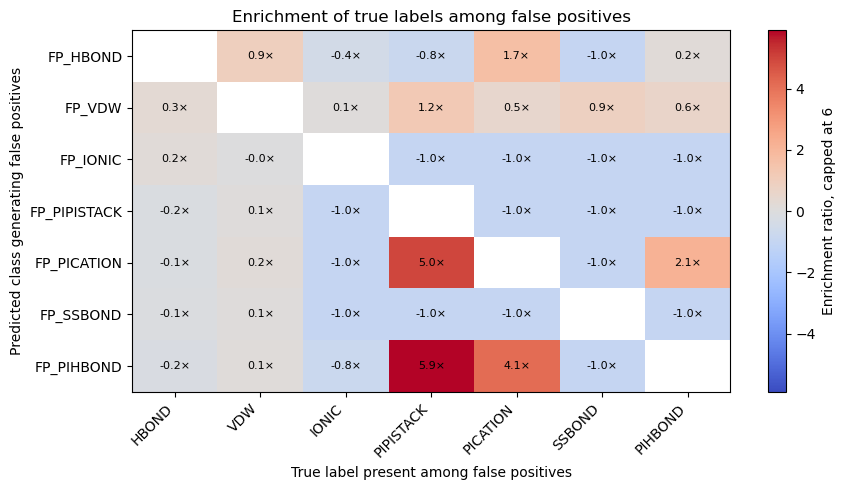

In [21]:
plot_df = enrichment_df.clip(upper=6) 

fig, ax = plt.subplots(figsize=(9, 5))

import matplotlib.colors as mcolors

vmax = np.nanmax(np.abs(plot_df.values))
vmin = -vmax

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

im = ax.imshow(
    plot_df,
    aspect="auto",
    cmap="coolwarm",
    norm=norm
)

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_yticks(np.arange(plot_df.shape[0]))

ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("True label present among false positives")
ax.set_ylabel("Predicted class generating false positives")
ax.set_title("Enrichment of true labels among false positives")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Enrichment ratio, capped at 6")

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        value = plot_df.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.1f}×", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()